# Optimizer comparison — Grid vs Random vs Optuna on identical memberships


## Goal
Compare three optimization backends over the **same dataset, folds, metric contract and discrete search domain**. This is not a final model comparison; it is an optimizer behavior study focusing on best score, candidate count, runtime and search efficiency.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("MLCORE_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from time import perf_counter
from sklearn.datasets import make_classification
from mlcore import tune
from mlcore.core import SearchSpace, Categorical
from mlcore.datasets import DatasetBundle, PartitionPlan
from mlcore.tuning import TuningConfig


In [2]:
X,y=make_classification(n_samples=140 if DEMO_TEST else 300,n_features=12,n_informative=8,class_sep=1.0,random_state=99)
ids=[f"optimizer_{i:04d}" for i in range(len(y))]
dataset=DatasetBundle(X=X,y=y,sample_ids=ids,feature_names=[f"f{i}" for i in range(X.shape[1])])
plan=PartitionPlan.from_predefined_folds(sample_ids=ids,fold_assignments=balanced_fold_labels(y,4),dataset_fingerprint=dataset.fingerprint)
space=SearchSpace("logreg_shared",{"C":Categorical([0.03,0.1,0.3,1.0,3.0,10.0]),"class_weight":Categorical([None,"balanced"]),"solver":Categorical(["lbfgs"])})


In [3]:
rows=[]; histories={}
for name in ("grid","random","optuna"):
    cfg=TuningConfig(optimizer=name,metrics=("mcc","roc_auc"),refit_metric="mcc",random_state=123,n_jobs=1,
                     n_iter=6 if DEMO_TEST else 10,n_trials=6 if DEMO_TEST else 16)
    t0=perf_counter(); res=tune(dataset=dataset,algorithm="logistic_regression",config=cfg,partition_plan=plan,search_space=space); elapsed=perf_counter()-t0
    hist=res.history_frame(); histories[name]=hist
    rows.append({"optimizer":name,"best_mcc":res.display_scores["mcc"],"best_roc_auc":res.display_scores["roc_auc"],
                 "elapsed_seconds":elapsed,"candidates":len(hist),"best_params":res.best_params})
summary=pd.DataFrame(rows).set_index("optimizer")
summary


[I 2026-09-13 18:20:56,390] A new study created in memory with name: no-name-8319cc63-169f-46ce-882c-a651acf432fa
[I 2026-09-13 18:20:56,433] Trial 0 finished with value: 0.6505362059813168 and parameters: {'C': 3.0, 'class_weight': None, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.6505362059813168.
[I 2026-09-13 18:20:56,491] Trial 1 finished with value: 0.6505362059813168 and parameters: {'C': 1.0, 'class_weight': 'balanced', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.6505362059813168.
[I 2026-09-13 18:20:56,543] Trial 2 finished with value: 0.6505362059813168 and parameters: {'C': 10.0, 'class_weight': None, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.6505362059813168.
[I 2026-09-13 18:20:56,597] Trial 3 finished with value: 0.6243435359425153 and parameters: {'C': 0.03, 'class_weight': 'balanced', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.6505362059813168.
[I 2026-09-13 18:20:56,648] Trial 4 finished with value: 0.6505362059813168 and parameters: {'C': 10

,best_mcc,best_roc_auc,elapsed_seconds,candidates,best_params
optimizer,,,,,
grid,0.650536,0.904525,1.294708,12,"{'C': 1.0, 'class_weight': None, 'solver': 'lb..."
random,0.650536,0.903603,1.041476,10,"{'solver': 'lbfgs', 'class_weight': 'balanced'..."
optuna,0.650536,0.903603,1.054092,16,"{'C': 3.0, 'class_weight': None, 'solver': 'lb..."


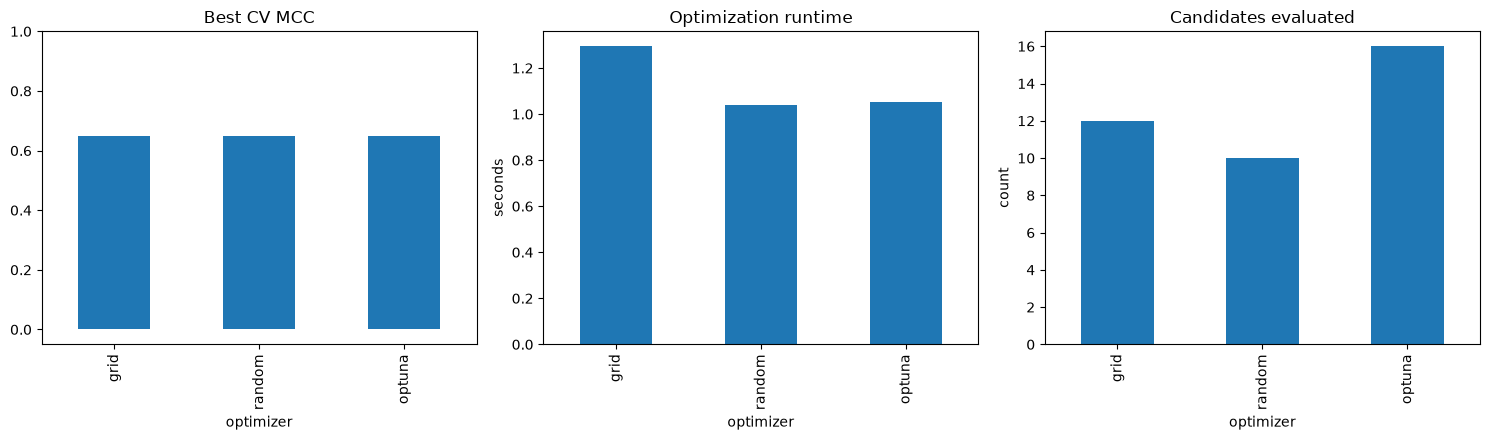

In [4]:
fig,axes=plt.subplots(1,3,figsize=(15,4.5))
summary.best_mcc.plot.bar(ax=axes[0]); axes[0].set(title="Best CV MCC",ylim=(-.05,1.0))
summary.elapsed_seconds.plot.bar(ax=axes[1]); axes[1].set(title="Optimization runtime",ylabel="seconds")
summary.candidates.plot.bar(ax=axes[2]); axes[2].set(title="Candidates evaluated",ylabel="count")
plt.tight_layout(); FIGURE_COUNT=1


In [5]:
DEMO_CHECKS={
    "three_optimizers":set(summary.index)=={"grid","random","optuna"},
    "finite_scores":np.isfinite(summary[["best_mcc","best_roc_auc"]].to_numpy()).all(),
    "histories_retained":all(len(v)>0 for v in histories.values()),
    "same_partition_contract":all(plan.fingerprint==plan.fingerprint for _ in histories),
    "figure_created":FIGURE_COUNT==1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'three_optimizers': True,
 'finite_scores': np.True_,
 'histories_retained': True,
 'same_partition_contract': True,
 'figure_created': True}